# Evaluating latent factors and firing rates inferred by `lfads-torch`

In [64]:
import re
from glob import glob
import numpy as np
from scipy.io import loadmat
from scipy.signal import lfilter
from scipy.signal.windows import gaussian
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load LFADS factors and rates from output files

In [65]:
LFADS_OUTPUT_PATHS = sorted(glob("lfads_output_pag_multisession_4_lfads*.h5"))
LFADS_OUTPUT_PATHS

['lfads_output_pag_multisession_4_lfads_Ctr.h5',
 'lfads_output_pag_multisession_4_lfads_EAA.h5']

In [66]:
# use train_inds and valid_inds to put data back to original order

def merge_data(train_data, valid_data, train_inds, valid_inds):
    n_neurons = train_data.shape[2]
    n_timepoints = train_data.shape[1]
    n_trials = train_data.shape[0] + valid_data.shape[0]
    merged_data = np.zeros((n_trials, n_timepoints, n_neurons))
    for i, ind in enumerate(train_inds):
        merged_data[ind] = train_data[i]
    for i, ind in enumerate(valid_inds):
        merged_data[ind] = valid_data[i]
    return merged_data

In [67]:
rates = {}
factors = {}
spikes = {}
inferred_inputs = {}
initial_conditions = {}
bin_width_sec = 0.1

for data_path in LFADS_OUTPUT_PATHS:
    session_id = data_path.rsplit('_', 1)[-1].split('.')[0]
    print(session_id)
    
    with h5py.File(data_path, 'r') as f:
        print(list(f.keys()))
        train_encod_data = f['train_encod_data'][:]
        valid_encod_data = f['valid_encod_data'][:]
        train_factors = f['train_factors'][:]
        valid_factors = f['valid_factors'][:]
        train_rates = f["train_output_params"][:]
        valid_rates = f["valid_output_params"][:]
        train_inferred_inputs = f['train_co_means'][:]
        valid_inferred_inputs = f['valid_co_means'][:]
        train_initial_conditions = f['train_ic_mean'][:]
        valid_initial_conditions = f['valid_ic_mean'][:]
        train_inds = f['train_inds'][:].astype(int)
        valid_inds = f['valid_inds'][:].astype(int)

        spikes[session_id] = merge_data(train_encod_data, valid_encod_data, train_inds, valid_inds)
        factors[session_id] = merge_data(train_factors, valid_factors, train_inds, valid_inds)
        rates[session_id] = merge_data(train_rates, valid_rates, train_inds, valid_inds)
        inferred_inputs[session_id] = merge_data(train_inferred_inputs, valid_inferred_inputs, train_inds, valid_inds)
        initial_conditions[session_id] = np.concatenate((train_initial_conditions, valid_initial_conditions), axis=0)


Ctr
['train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data']
EAA
['train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data']


In [68]:
factors['Ctr'].shape

(32, 300, 40)

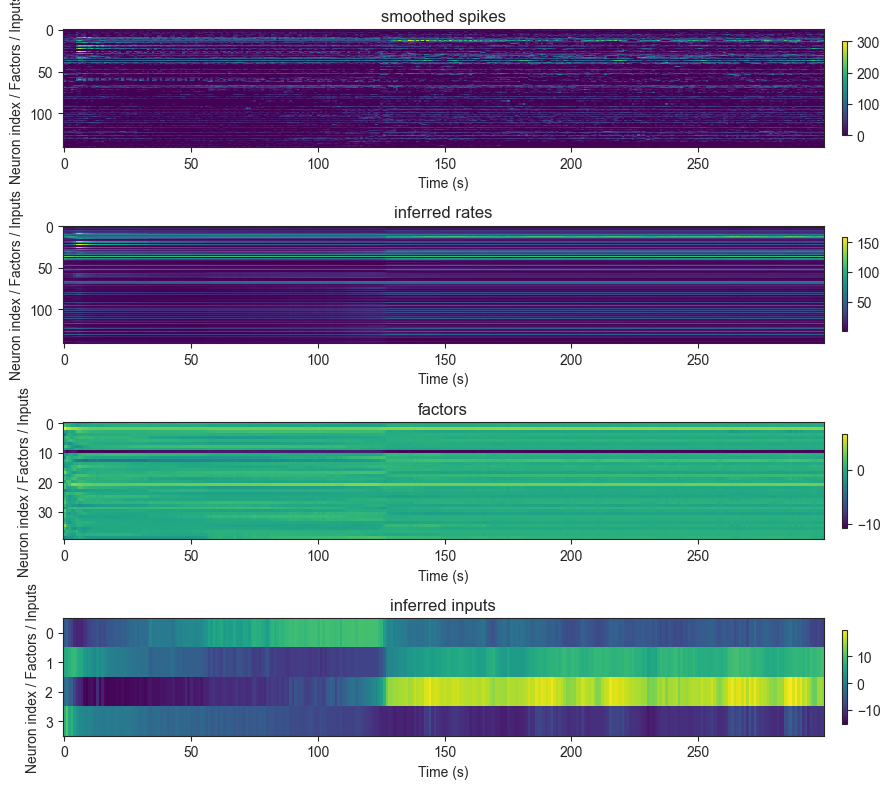

In [69]:
import matplotlib.pyplot as plt

# Visualize raw spikes, smoothed spikes, LFADS rates, and LFADS factors for a single trial
session = "EAA"
trial = 0
data = {
    "smoothed spikes": spikes[session][trial],
    "inferred rates": rates[session][trial],
    "factors": factors[session][trial],
    "inferred inputs": inferred_inputs[session][trial]
}

fig, axes = plt.subplots(nrows=4, figsize=(10, 8))
for ax, (name, data_val) in zip(axes, data.items()):
    im = ax.imshow(data_val.T, aspect='auto', interpolation='none', cmap='viridis')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neuron index / Factors / Inputs')
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
plt.tight_layout()

As an additional check, we can plot the PSTHs of the LFADS rates to verify if they are comparable to the empirical PSTHs obtained using smoothed spikes.
For simplicity, we do this for a single session and 20 neurons below.

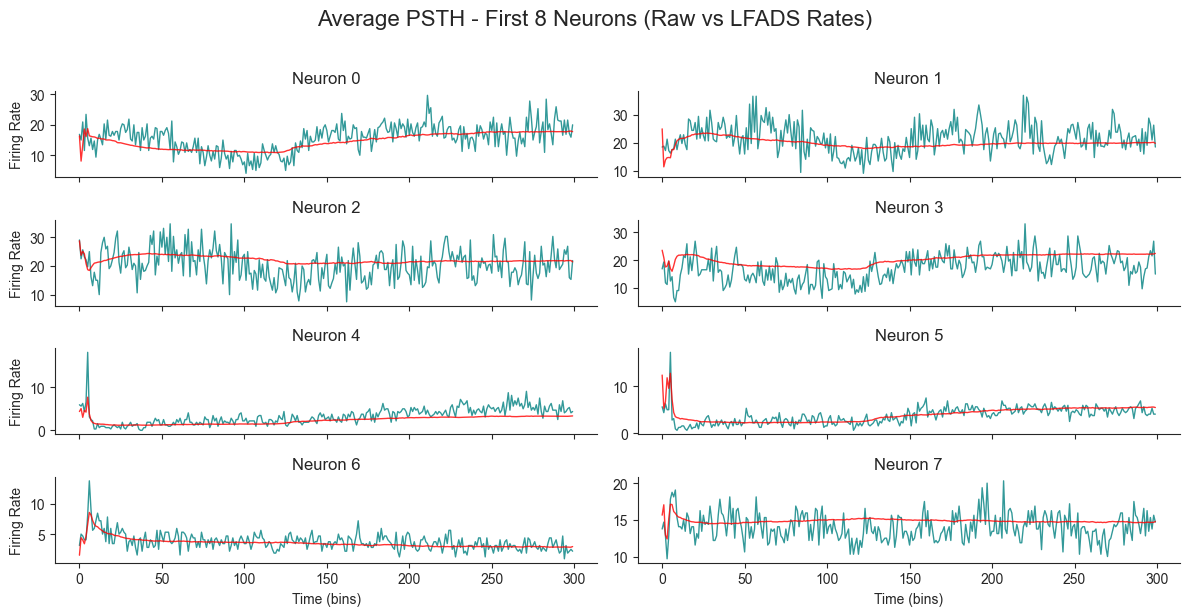

In [70]:
def plot_overlay_psths_first_8(spikes_data, rates_data, title):
    # Create a 4x2 grid to fit exactly 8 neurons
    fig, axes = plt.subplots(4, 2, figsize=(12, 6), sharex=True)
    
    # Flatten the axes array to easily iterate through all 8 subplots
    axes_flat = axes.flatten()
    
    for i in range(8):
        ax = axes_flat[i]
        
        # Calculate the mean across all trials for the i-th neuron
        spikes_mean_activity = np.mean(spikes_data[:, :, i], axis=0)
        rates_mean_activity = np.mean(rates_data[:, :, i], axis=0)
        
        ax.plot(spikes_mean_activity, color='teal', linewidth=1, alpha=0.8)
        ax.plot(rates_mean_activity, color='red', linewidth=1, alpha=0.8)
        ax.set_title(f"Neuron {i}", fontsize=12)
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 6:
            ax.set_xlabel("Time (bins)")
        if i % 2 == 0:
            ax.set_ylabel("Firing Rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'Ctr'
# Run the updated plotting function
plot_overlay_psths_first_8(spikes[sess], rates[sess], "Average PSTH - First 8 Neurons (Raw vs LFADS Rates)")

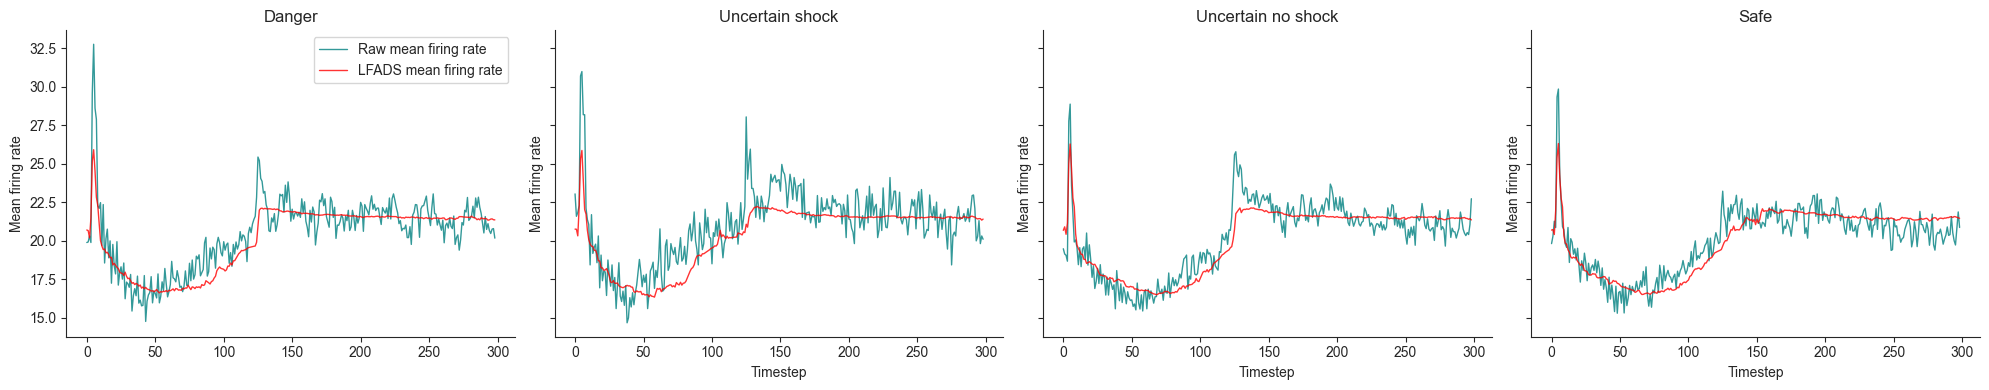

In [89]:
# Overlay firing rates for all neurons grouped by condition

def plot_denoised_rates_by_condition(spikes_data, rates_data, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']

    mean_spikes_danger = np.mean(np.mean(spikes_data[0:4, :, :], axis=2), axis=0)
    mean_spikes_unc_noshock = np.mean(np.mean(spikes_data[4:6, :, :], axis=2), axis=0)
    mean_spikes_unc_shock = np.mean(np.mean(spikes_data[6:11, :, :], axis=2), axis=0)
    mean_spikes_safety = np.mean(np.mean(spikes_data[11:15, :, :], axis=2), axis=0)

    spikes = [mean_spikes_danger, mean_spikes_unc_noshock, mean_spikes_unc_shock, mean_spikes_safety]

    mean_rates_danger = np.mean(np.mean(rates_data[0:4, :, :], axis=2), axis=0)
    mean_rates_unc_noshock = np.mean(np.mean(rates_data[4:6, :, :], axis=2), axis=0)
    mean_rates_unc_shock = np.mean(np.mean(rates_data[6:11, :, :], axis=2), axis=0)
    mean_rates_safety = np.mean(np.mean(rates_data[11:15, :, :], axis=2), axis=0)

    rates = [mean_rates_danger, mean_rates_unc_noshock, mean_rates_unc_shock, mean_rates_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(spikes[i][1:], color='teal', linewidth=1, alpha=0.8, label='Raw mean firing rate')
        ax.plot(rates[i][1:], color='red', linewidth=1, alpha=0.8, label='LFADS mean firing rate')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 1:
            ax.set_xlabel("Timestep")
        if i % 1 == 0:
            ax.set_ylabel("Mean firing rate")

    # plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'EAA'
# Run the updated plotting function
plot_denoised_rates_by_condition(spikes[sess], rates[sess], "Average firing rates by condition (mean across all neurons)")

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

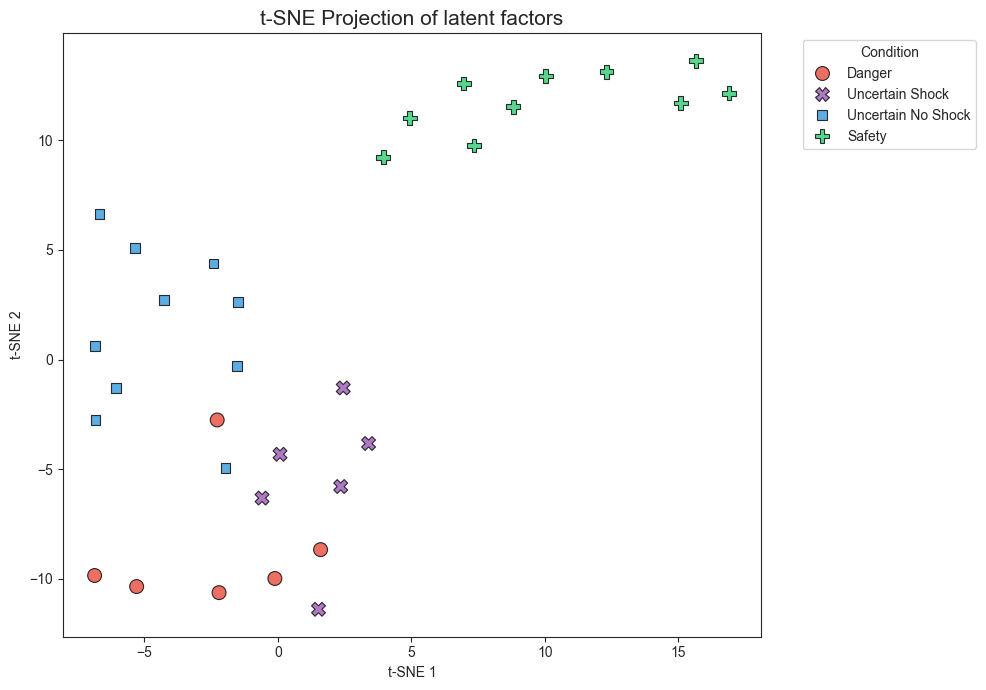

In [90]:
# t-SNE clustering of factors

def plot_tsne_factors(data_array):
    """
    Projects trial data to 2D using t-SNE and colors by condition.
    data_array: np.ndarray of shape (n_trials, n_timesteps, n_inputs)
    """
    # flatten the data: (32, 495, 60) -> (32, 495*60)
    n_trials, n_time, n_inputs = data_array.shape
    flattened_data = data_array.reshape(n_trials, -1)

    # 2. Define the conditions based on your trial counts
    # 4 Danger, 2 Uncertain Shock, 6 Uncertain No Shock, 4 Safety
    conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 3. Run t-SNE
    # perplexity should be smaller than n_samples (32)
    tsne = TSNE(n_components=2, perplexity=10, random_state=47, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(flattened_data)

    # 4. Visualization
    plt.figure(figsize=(10, 7))
    sns.set_style("ticks")
    
    # Custom color palette for conditions
    palette = {
        'Danger': '#e74c3c',            # Red
        'Uncertain Shock': '#9b59b6',   # Purple
        'Uncertain No Shock': '#3498db',# Blue
        'Safety': '#2ecc71'             # Green
    }

    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1], 
        hue=conditions,
        palette=palette,
        s=100,
        style=conditions,
        edgecolor='black',
        alpha=0.8
    )

    plt.title('t-SNE Projection of latent factors', fontsize=15)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_tsne_factors(factors['Ctr'])

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'PCA Projection'}, xlabel='PC 1 (49.3% Var)', ylabel='PC 2 (28.6% Var)'>)

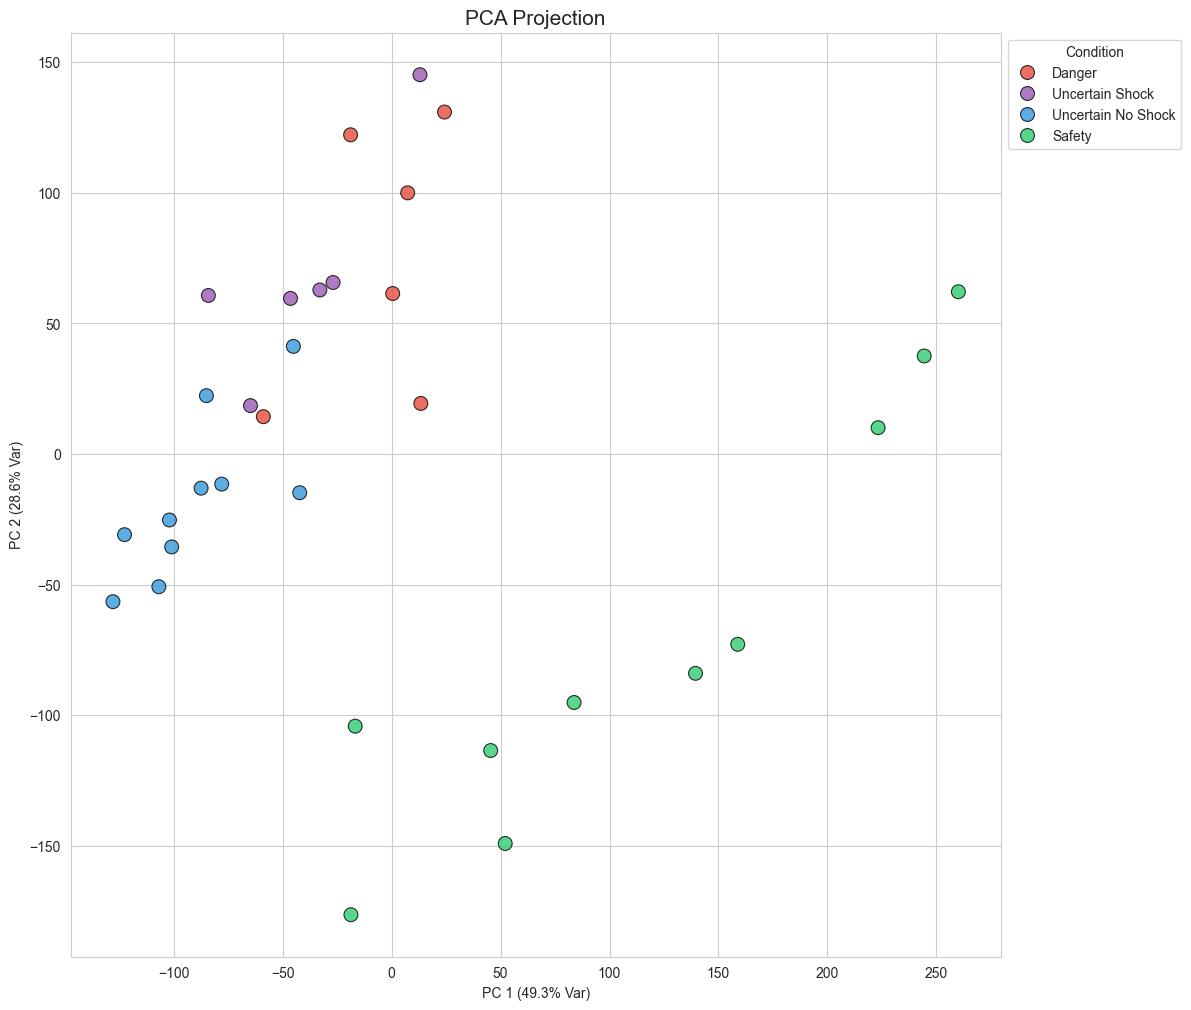

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array, title='PCA Projection', ax=None):
    """
    Performs PCA on reshaped (Trials, Time * Dimensions) data and plots 
    on a provided axis for subplot integration.
    """
    # 1. Reshape: (Trials, Time, Dim) --> (Trials, Time * Dim)
    n_trials, n_time, n_dim = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)
    
    # 2. Handle Axis/Figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 12))
    else:
        fig = ax.get_figure()

    # 3. Define labels (Ensure they match n_trials)
    base_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )
    current_conditions = base_conditions[:n_trials]

    # 4. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 5. Visualization
    sns.set_style("whitegrid")
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=current_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black',
        ax=ax  # This tells seaborn to use your specific subplot
    )

    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    ax.set_ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    
    # Legend handling: move it outside the plot area
    ax.legend(title='Condition', bbox_to_anchor=(1, 1), loc='upper left')
    
    return fig, ax

plot_pca_stacked_inputs(inferred_inputs['Ctr'][:, 120:, :])

In [75]:
inferred_inputs['EAA'].shape

(32, 300, 4)

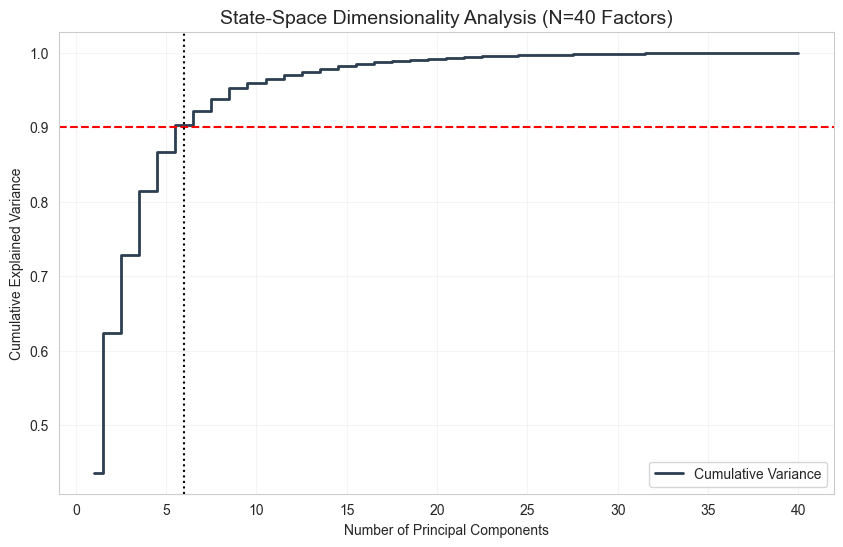

--- State-Space Analysis ---
Total Factors in Model: 40
Intrinsic Dimensionality (>90%): 6


In [76]:
def analyze_pca_variance(data_array, threshold=0.90):
    """
    Analyzes dimensionality across the 'Factors' dimension.
    data_array: (n_trials, n_timepoints, n_factors)
    """
    # 1. Reshape: Stack all trials and timepoints
    # Resulting shape: (Total_Timepoints, n_factors)
    n_trials, n_time, n_factors = data_array.shape
    state_space_data = data_array.reshape(-1, n_factors)
    
    # 2. Fit PCA on the factor dimension
    pca = PCA()
    pca.fit(state_space_data)
    
    # 3. Calculate Variance Metrics
    exp_var_ratio = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(exp_var_ratio)
    
    # 4. Find threshold
    n_pcs_needed = np.argmax(cumulative_var >= threshold) + 1
    
    # 5. Plotting
    plt.figure(figsize=(10, 6))
    plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid',
             label='Cumulative Variance', color='#2c3e50', lw=2)


    plt.axhline(y=threshold, color='r', linestyle='--')
    plt.axvline(x=n_pcs_needed, color='black', linestyle=':')
    
    plt.title(f'State-Space Dimensionality Analysis (N={n_factors} Factors)', fontsize=14)
    plt.ylabel('Cumulative Explained Variance')
    plt.xlabel('Number of Principal Components')
    plt.xticks(range(0, n_factors + 1, 5))
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f"--- State-Space Analysis ---")
    print(f"Total Factors in Model: {n_factors}")
    print(f"Intrinsic Dimensionality (>{int(threshold*100)}%): {n_pcs_needed}")
    
    return n_pcs_needed

# Example usage with your LFADS factors:
results = analyze_pca_variance(factors['EAA'])

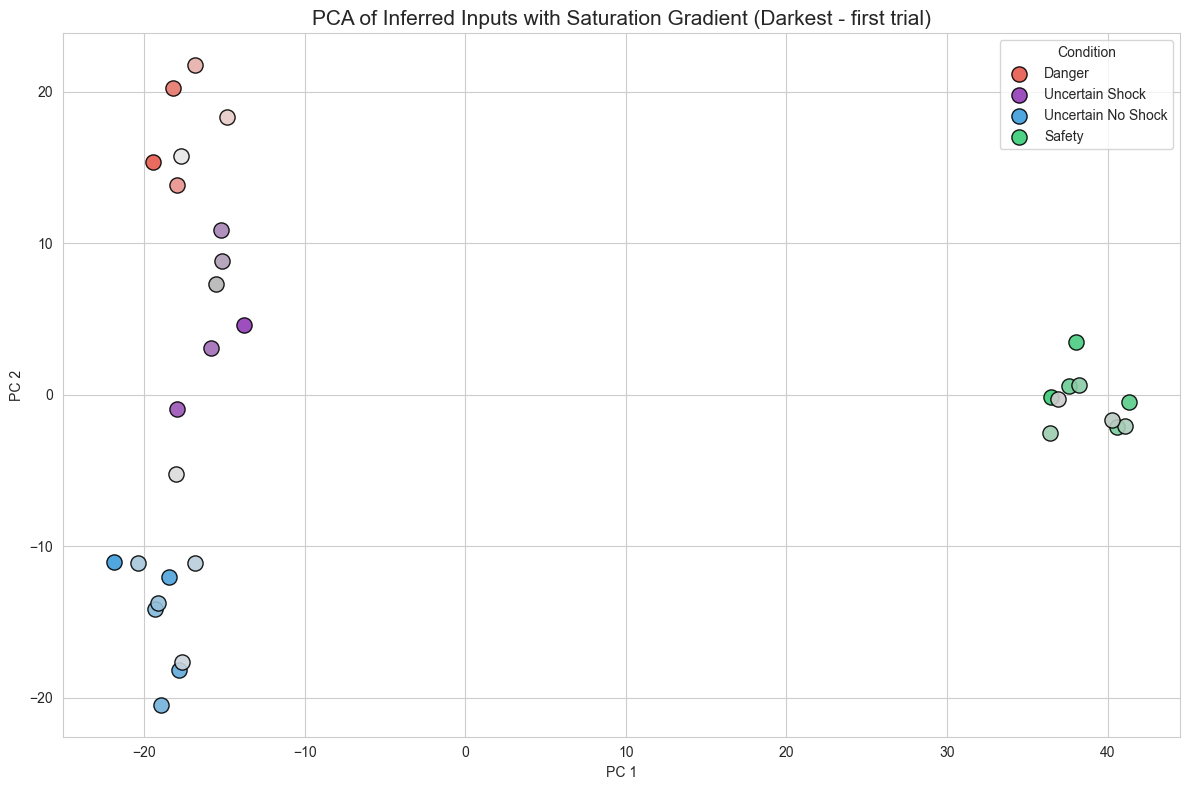

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
import colorsys

def plot_pca_with_saturation(data_array):
    # 1. Prepare data
    n_trials, n_time, n_inputs = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)

    # 2. Define trial counts per condition
    condition_counts = {
        'Danger': 6,
        'Uncertain Shock': 6,
        'Uncertain No Shock': 10,
        'Safety': 10
    }
    
    # Base colors (Hex)
    base_palette = {
        'Danger': '#e74c3c',            # Red
        'Uncertain Shock': '#9b59b6',   # Purple
        'Uncertain No Shock': '#3498db',# Blue
        'Safety': '#2ecc71'             # Green
    }

    # 3. Generate labels and trial-specific colors
    labels = []
    trial_colors = []
    
    for cond, count in condition_counts.items():
        base_rgb = mcolors.to_rgb(base_palette[cond])
        # Convert RGB to HSV
        h, s, v = colorsys.rgb_to_hsv(*base_rgb)
        
        for i in range(count):
            labels.append(cond)
            saturation_level = 1 - (0.2 + (0.8 * ((i + 1) / count)))
            
            # Convert back to RGB with new saturation
            new_rgb = colorsys.hsv_to_rgb(h, saturation_level, v)
            trial_colors.append(new_rgb)

    # 4. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)

    # 5. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    # Plot each point individually to apply specific color
    for i in range(n_trials):
        plt.scatter(
            pca_results[i, 0], 
            pca_results[i, 1], 
            color=trial_colors[i],
            s=120, 
            edgecolor='black',
            alpha=0.9,
            label=labels[i] if labels[i] not in plt.gca().get_legend_handles_labels()[1] else ""
        )

    plt.title('PCA of Inferred Inputs with Saturation Gradient (Darkest - first trial)', fontsize=15)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend(title='Condition', bbox_to_anchor=(1.00, 1), loc='upper right')
    plt.tight_layout()
    plt.show()

plot_pca_with_saturation(factors['EAA'])

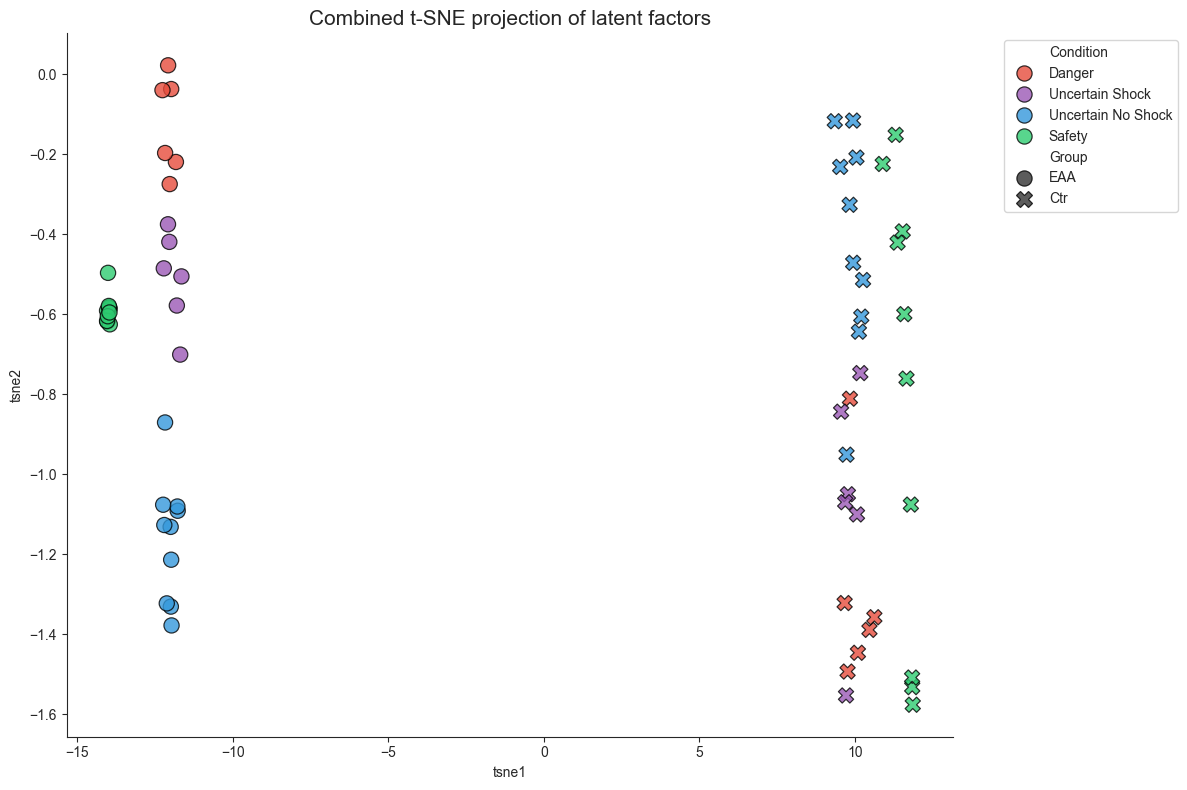

In [97]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne_combined(data_array_EAA, data_array_Ctr, title="Combined t-SNE projection of latent factors"):
    # 1. Flatten and Concatenate
    # shape: (n_trials, n_time * n_inputs)
    flat_EAA = data_array_EAA.reshape(data_array_EAA.shape[0], -1)
    flat_Ctr = data_array_Ctr.reshape(data_array_Ctr.shape[0], -1)
    
    # Combined data for t-SNE
    combined_data = np.concatenate([flat_EAA, flat_Ctr], axis=0)

    # 2. Create labels for both dimensions (Condition and Group)
    single_session_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )
    # Double the conditions (once for EAA, once for Ctr)
    all_conditions = single_session_conditions + single_session_conditions
    # Group labels
    groups = ['EAA'] * len(single_session_conditions) + ['Ctr'] * len(single_session_conditions)

    # 3. Run t-SNE on the combined dataset
    tsne = TSNE(n_components=2, perplexity=25, random_state=47, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(combined_data)

    # 4. Create a DataFrame for Seaborn
    df = pd.DataFrame({
        'tsne1': tsne_results[:, 0],
        'tsne2': tsne_results[:, 1],
        'Condition': all_conditions,
        'Group': groups
    })

    # 5. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("ticks")
    
    palette = {
        'Danger': '#e74c3c',
        'Uncertain Shock': '#9b59b6',
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    # Use 'hue' for Condition and 'style' for Group (EAA vs Ctr)
    sns.scatterplot(
        data=df,
        x='tsne1', y='tsne2',
        hue='Condition',
        style='Group',
        palette=palette,
        s=120,
        edgecolor='black',
        alpha=0.8
    )

    plt.title(title, fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run it
plot_tsne_combined(factors['EAA'], factors['Ctr'])

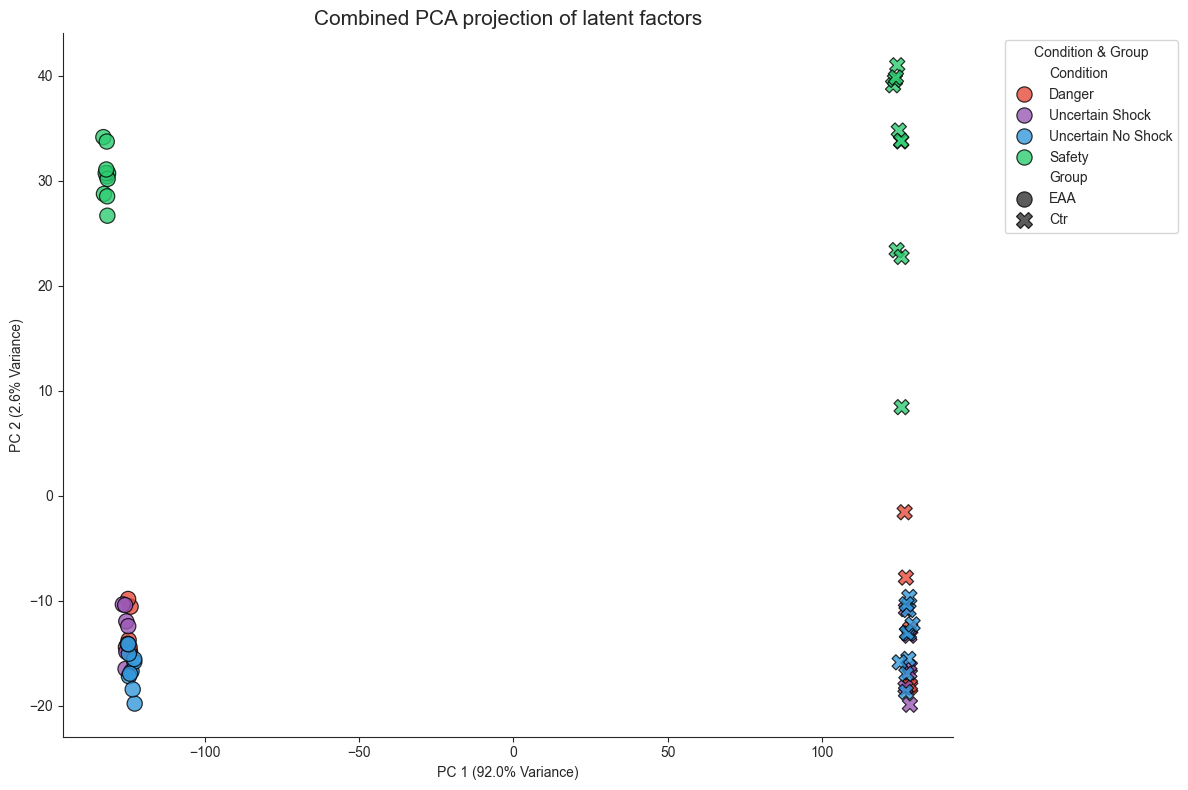

In [79]:
def plot_pca_combined(data_array_EAA, data_array_Ctr, title="Combined PCA projection of inferred inputs"):
    # 1. Flatten and Concatenate
    # Shapes: (n_trials, n_time, n_inputs) -> (n_trials, n_time * n_inputs)
    flat_EAA = data_array_EAA.reshape(data_array_EAA.shape[0], -1)
    flat_Ctr = data_array_Ctr.reshape(data_array_Ctr.shape[0], -1)
    
    # Combined data for shared PCA space
    combined_data = np.concatenate([flat_EAA, flat_Ctr], axis=0)

    # 2. Define labels (Conditions and Groups)
    # Adjust counts based on your trial structure
    single_session_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )
    
    all_conditions = single_session_conditions + single_session_conditions
    groups = ['EAA'] * len(single_session_conditions) + ['Ctr'] * len(single_session_conditions)

    # 3. Run PCA on the combined dataset
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(combined_data)
    var_expl = pca.explained_variance_ratio_ * 100

    # 4. Create DataFrame for Seaborn
    import pandas as pd
    df = pd.DataFrame({
        'PC1': pca_results[:, 0],
        'PC2': pca_results[:, 1],
        'Condition': all_conditions,
        'Group': groups
    })

    # 5. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("ticks")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        data=df,
        x='PC1', 
        y='PC2', 
        hue='Condition',
        style='Group', # Different shapes for EAA and Ctr
        palette=palette,
        s=120,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title(title, fontsize=15)
    plt.xlabel(f'PC 1 ({var_expl[0]:.1f}% Variance)')
    plt.ylabel(f'PC 2 ({var_expl[1]:.1f}% Variance)')
    plt.legend(title='Condition & Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run the combined PCA
plot_pca_combined(factors['EAA'], factors['Ctr'], 'Combined PCA projection of latent factors')

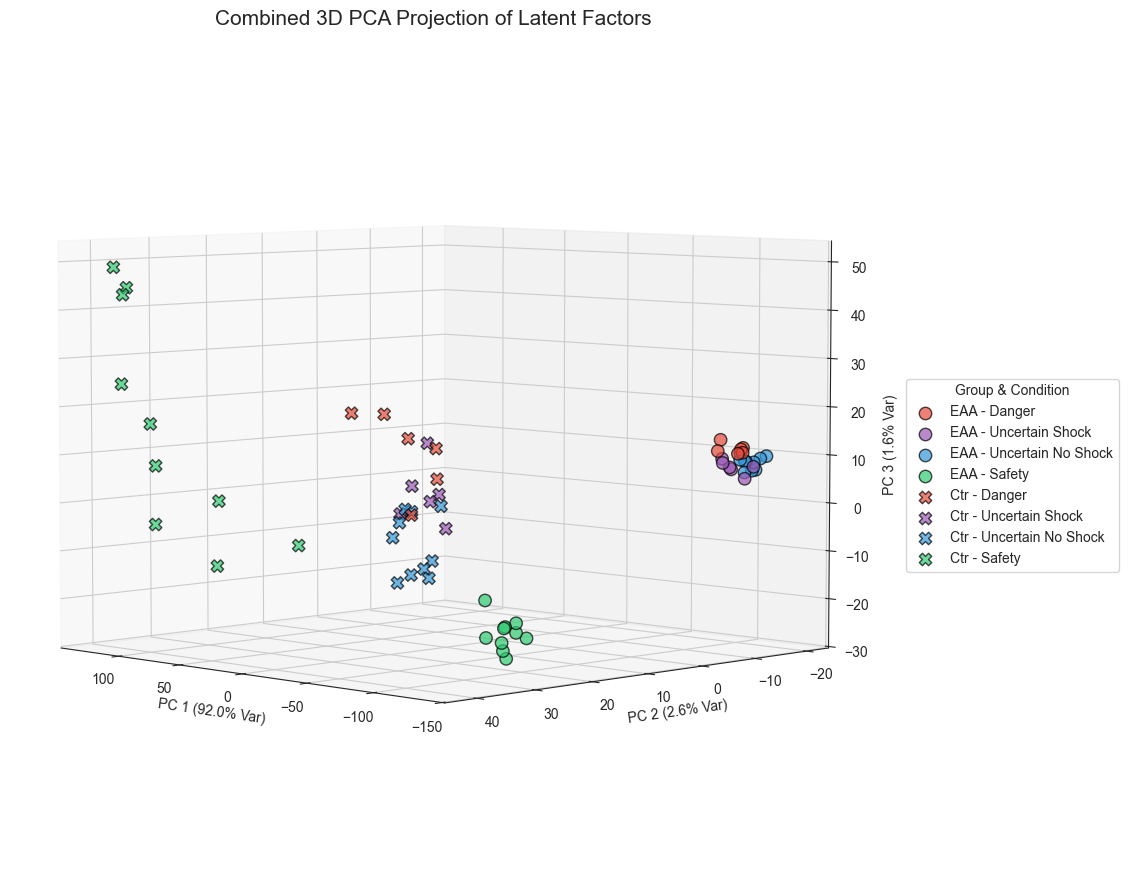

In [99]:
def plot_pca_combined_3d(data_array_EAA, data_array_Ctr, title="Combined 3D PCA projection", elev=10, azim=135):
    # 1. Flatten and Concatenate
    flat_EAA = data_array_EAA.reshape(data_array_EAA.shape[0], -1)
    flat_Ctr = data_array_Ctr.reshape(data_array_Ctr.shape[0], -1)
    combined_data = np.concatenate([flat_EAA, flat_Ctr], axis=0)

    # 2. Define labels
    single_session_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )
    all_conditions = single_session_conditions + single_session_conditions
    groups = ['EAA'] * len(single_session_conditions) + ['Ctr'] * len(single_session_conditions)

    # 3. Run PCA for 3 components
    pca = PCA(n_components=3)
    pca_results = pca.fit_transform(combined_data)
    var_expl = pca.explained_variance_ratio_ * 100

    # 4. Visualization Setup
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }
    
    # Map markers to Groups (Circle for EAA, Square/X for Ctr)
    markers = {'EAA': 'o', 'Ctr': 'X'}

    # 5. Plotting points individually to handle hue/style manually
    for group in ['EAA', 'Ctr']:
        for condition in palette.keys():
            # Create a mask for rows matching this group and condition
            mask = (np.array(groups) == group) & (np.array(all_conditions) == condition)
            
            if np.any(mask):
                ax.scatter(
                    pca_results[mask, 0], 
                    pca_results[mask, 1], 
                    pca_results[mask, 2],
                    label=f"{group} - {condition}",
                    color=palette[condition],
                    marker=markers[group],
                    s=80,
                    edgecolor='black',
                    alpha=0.7
                )

    # Labeling
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f'PC 1 ({var_expl[0]:.1f}% Var)')
    ax.set_ylabel(f'PC 2 ({var_expl[1]:.1f}% Var)')
    ax.set_zlabel(f'PC 3 ({var_expl[2]:.1f}% Var)')
    
    # Legend - placing it outside the plot
    ax.legend(title='Group & Condition', bbox_to_anchor=(1.05, 0.6), loc='upper left')
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()

# Run the 3D PCA
plot_pca_combined_3d(factors['EAA'], factors['Ctr'], 'Combined 3D PCA Projection of Latent Factors', elev=5, azim=135)

# Inferred inputs analysis

### plot inferred inputs, EAA vs control

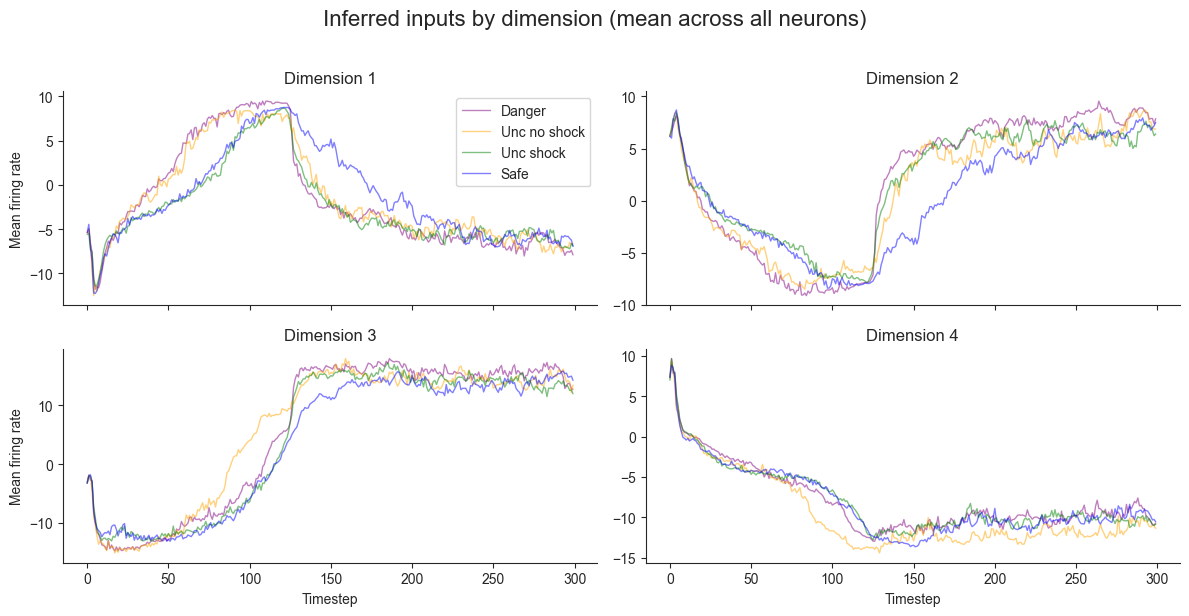

In [81]:
# plot 4 conditions for each dimension of inferred inputs

def plot_inferred_inputs_by_dimension(input_data, title):
    # Create a 2x2 grid to fit exactly 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    dimensions = ['Dimension 1', 'Dimension 2', 'Dimension 3', 'Dimension 4']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    danger = [inputs_dim0_danger, inputs_dim1_danger, inputs_dim2_danger, inputs_dim3_danger]
    unc_noshock = [inputs_dim0_unc_noshock, inputs_dim1_unc_noshock, inputs_dim2_unc_noshock, inputs_dim3_unc_noshock]
    unc_shock = [inputs_dim0_unc_shock, inputs_dim1_unc_shock, inputs_dim2_unc_shock, inputs_dim3_unc_shock]
    safety = [inputs_dim0_safety, inputs_dim1_safety, inputs_dim2_safety, inputs_dim3_safety]

    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(danger[i], color='purple', linewidth=1, alpha=0.5, label='Danger')
        ax.plot(unc_noshock[i], color='orange', linewidth=1, alpha=0.5, label='Unc no shock')
        ax.plot(unc_shock[i], color='green', linewidth=1, alpha=0.5, label='Unc shock')
        ax.plot(safety[i], color='blue', linewidth=1, alpha=0.5, label='Safe')
        ax.set_title(dimensions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'EAA'
# Run the updated plotting function
plot_inferred_inputs_by_dimension(inferred_inputs[sess], "Inferred inputs by dimension (mean across all neurons)")

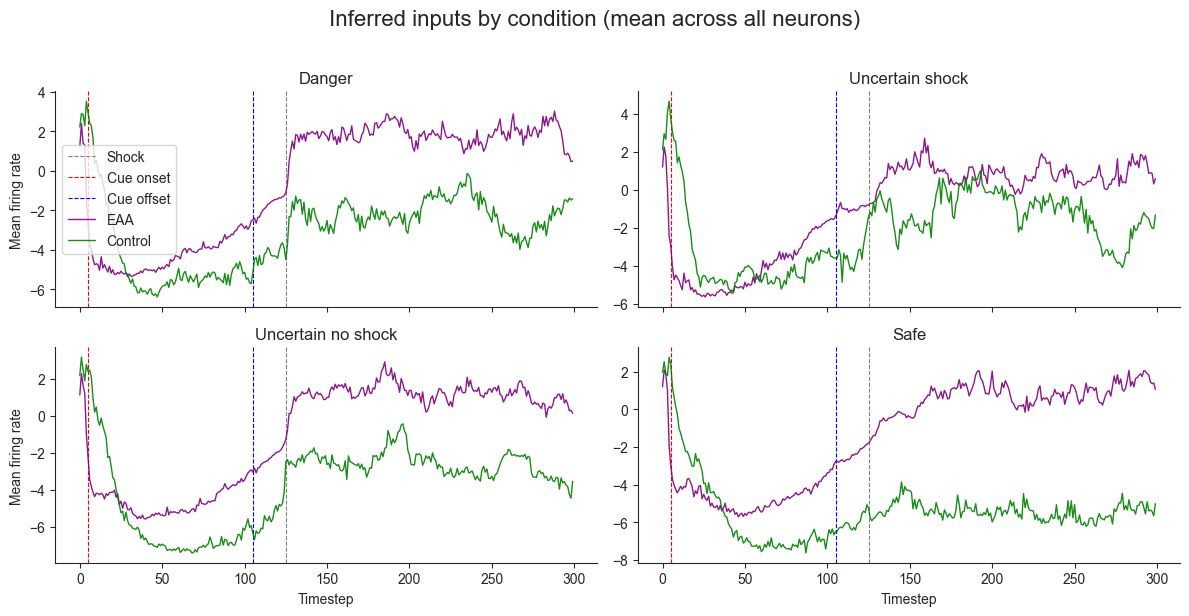

In [82]:
# plot inferred inputs for each condition

def plot_inferred_inputs_by_group(input_data_EAA, input_data_Ctr, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_EAA_danger = np.mean(input_data_EAA[0:4, :, :], axis=(0, 2))
    inputs_EAA_unc_noshock = np.mean(input_data_EAA[4:6, :, :], axis=(0, 2))
    inputs_EAA_unc_shock = np.mean(input_data_EAA[6:11, :, :], axis=(0, 2))
    inputs_EAA_safety = np.mean(input_data_EAA[11:15, :, :], axis=(0, 2))
    inputs_EAA = [inputs_EAA_danger, inputs_EAA_unc_noshock, inputs_EAA_unc_shock, inputs_EAA_safety]

    inputs_Ctr_danger = np.mean(input_data_Ctr[0:4, :, :], axis=(0, 2))
    inputs_Ctr_unc_noshock = np.mean(input_data_Ctr[4:6, :, :], axis=(0, 2))
    inputs_Ctr_unc_shock = np.mean(input_data_Ctr[6:11, :, :], axis=(0, 2))
    inputs_Ctr_safety = np.mean(input_data_Ctr[11:15, :, :], axis=(0, 2))
    inputs_Ctr = [inputs_Ctr_danger, inputs_Ctr_unc_noshock, inputs_Ctr_unc_shock, inputs_Ctr_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        ax.axvline(x=125, label='Shock', color='grey', linestyle='--', linewidth=0.8)
        ax.axvline(x=5, label='Cue onset', color='red', linestyle='--', linewidth=0.8)
        ax.axvline(x=105, label='Cue offset', color='blue', linestyle='--', linewidth=0.8)
        ax.plot(inputs_EAA[i], color='purple', linewidth=1, alpha=0.9, label='EAA')
        ax.plot(inputs_Ctr[i], color='green', linewidth=1, alpha=0.9, label='Control')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_inferred_inputs_by_group(inferred_inputs['EAA'], inferred_inputs['Ctr'], "Inferred inputs by condition (mean across all neurons)")

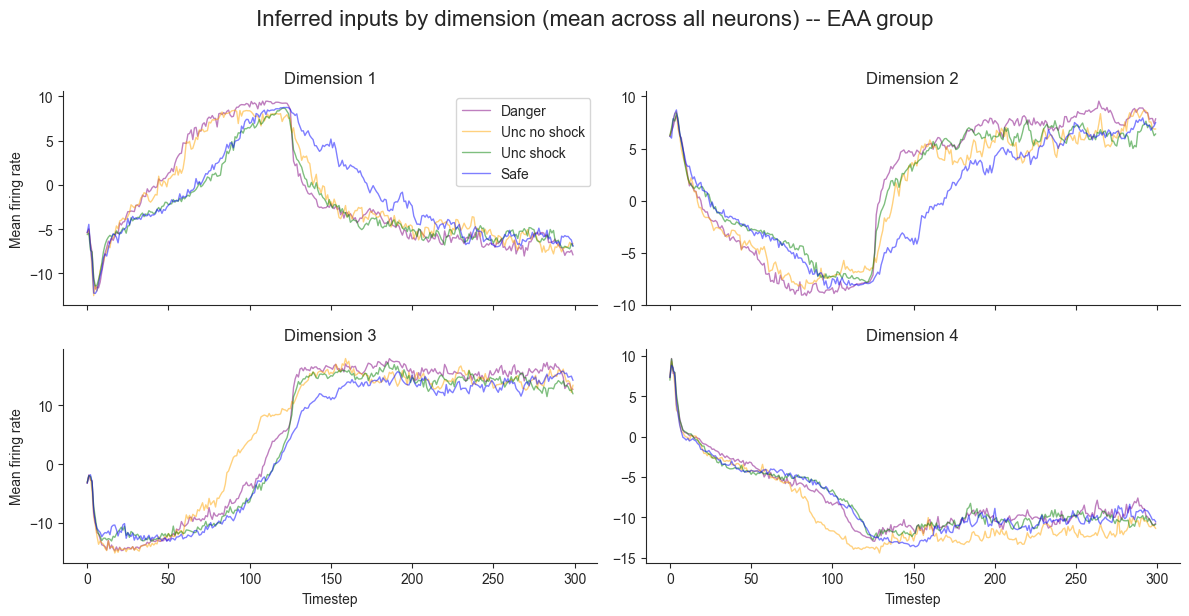

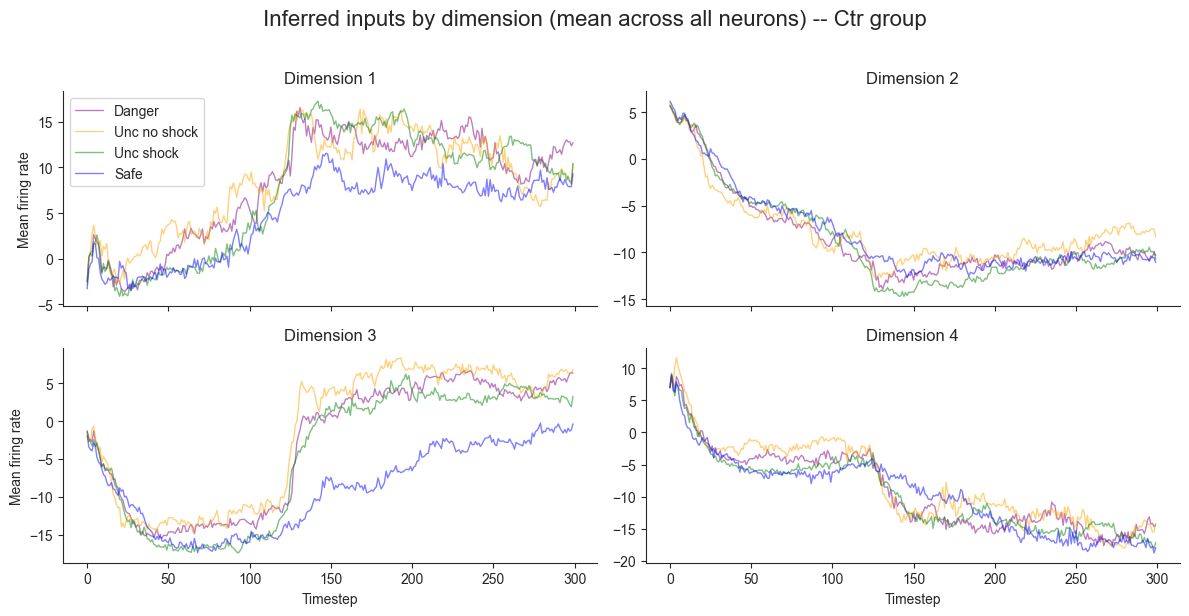

In [83]:
# plot 4 conditions for each dimension of inferred inputs

def plot_inferred_inputs_by_dimension(input_data, title):
    # Create a 2x2 grid to fit exactly 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    dimensions = ['Dimension 1', 'Dimension 2', 'Dimension 3', 'Dimension 4']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    danger = [inputs_dim0_danger, inputs_dim1_danger, inputs_dim2_danger, inputs_dim3_danger]
    unc_noshock = [inputs_dim0_unc_noshock, inputs_dim1_unc_noshock, inputs_dim2_unc_noshock, inputs_dim3_unc_noshock]
    unc_shock = [inputs_dim0_unc_shock, inputs_dim1_unc_shock, inputs_dim2_unc_shock, inputs_dim3_unc_shock]
    safety = [inputs_dim0_safety, inputs_dim1_safety, inputs_dim2_safety, inputs_dim3_safety]

    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(danger[i], color='purple', linewidth=1, alpha=0.5, label='Danger')
        ax.plot(unc_noshock[i], color='orange', linewidth=1, alpha=0.5, label='Unc no shock')
        ax.plot(unc_shock[i], color='green', linewidth=1, alpha=0.5, label='Unc shock')
        ax.plot(safety[i], color='blue', linewidth=1, alpha=0.5, label='Safe')
        ax.set_title(dimensions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_inferred_inputs_by_dimension(inferred_inputs['EAA'], "Inferred inputs by dimension (mean across all neurons) -- EAA group")
plot_inferred_inputs_by_dimension(inferred_inputs['Ctr'], "Inferred inputs by dimension (mean across all neurons) -- Ctr group")

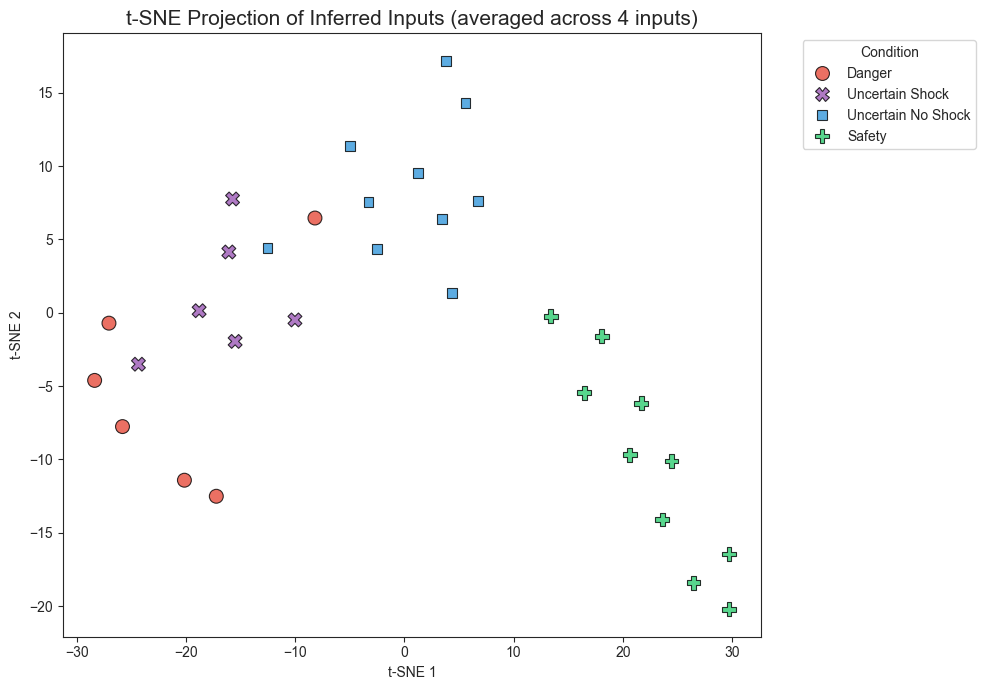

In [84]:
# t-SNE clustering of inferred inputs

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_tsne_conditions(data_array):
    """
    Projects trial data to 2D using t-SNE and colors by condition.
    data_array: np.ndarray of shape (n_trials, n_timesteps, n_inputs)
    """
    # 1. Flatten the data: (16, 400, 4) -> (16, 1600)
    n_trials, n_time, n_inputs = data_array.shape
    flattened_data = data_array.reshape(n_trials, -1)

    # 2. Define the conditions based on your trial counts
    # 4 Danger, 2 Uncertain Shock, 6 Uncertain No Shock, 4 Safety
    conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 3. Run t-SNE
    # perplexity should be smaller than n_samples (32)
    tsne = TSNE(n_components=2, perplexity=8, random_state=44, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(flattened_data)

    # 4. Visualization
    plt.figure(figsize=(10, 7))
    sns.set_style("ticks")
    
    # Custom color palette for conditions
    palette = {
        'Danger': '#e74c3c',            # Red
        'Uncertain Shock': '#9b59b6',   # Purple
        'Uncertain No Shock': '#3498db',# Blue
        'Safety': '#2ecc71'             # Green
    }

    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1], 
        hue=conditions,
        palette=palette,
        s=100,
        style=conditions,
        edgecolor='black',
        alpha=0.8
    )

    plt.title('t-SNE Projection of Inferred Inputs (averaged across 4 inputs)', fontsize=15)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_tsne_conditions(inferred_inputs['Ctr'])

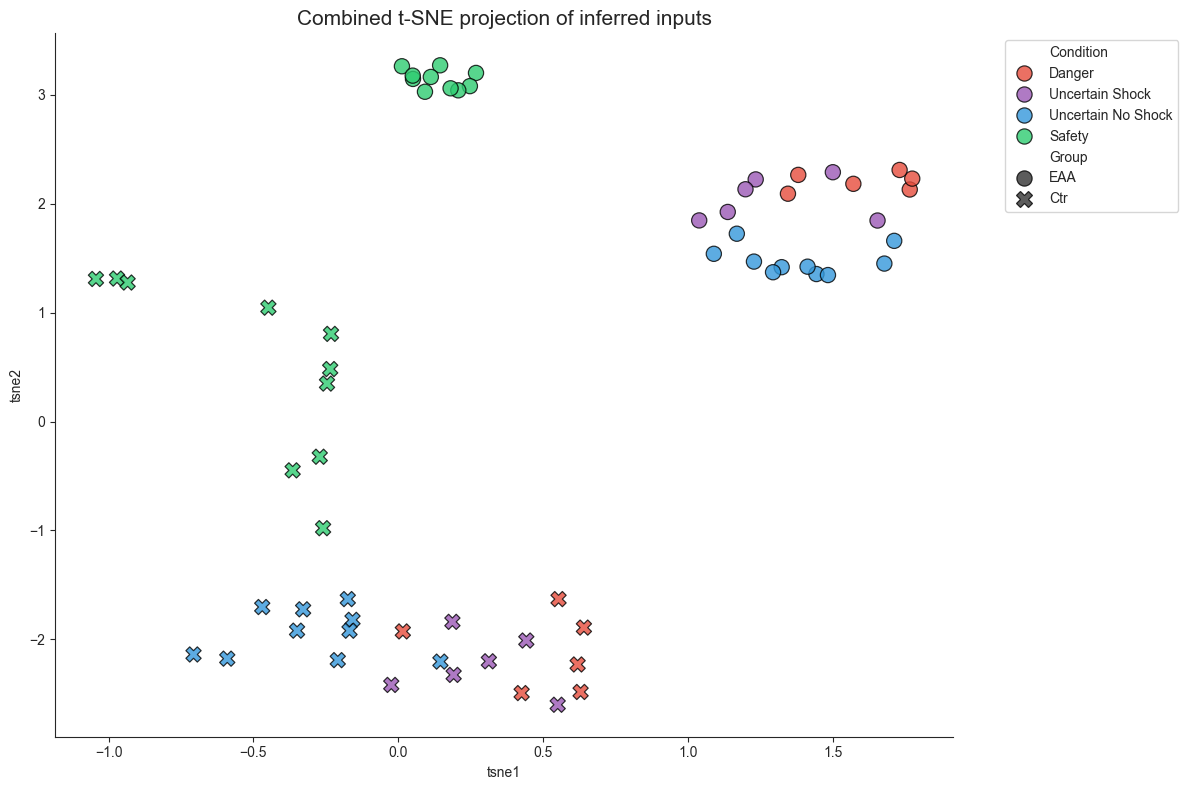

In [85]:
plot_tsne_combined(inferred_inputs['EAA'], inferred_inputs['Ctr'], 'Combined t-SNE projection of inferred inputs')

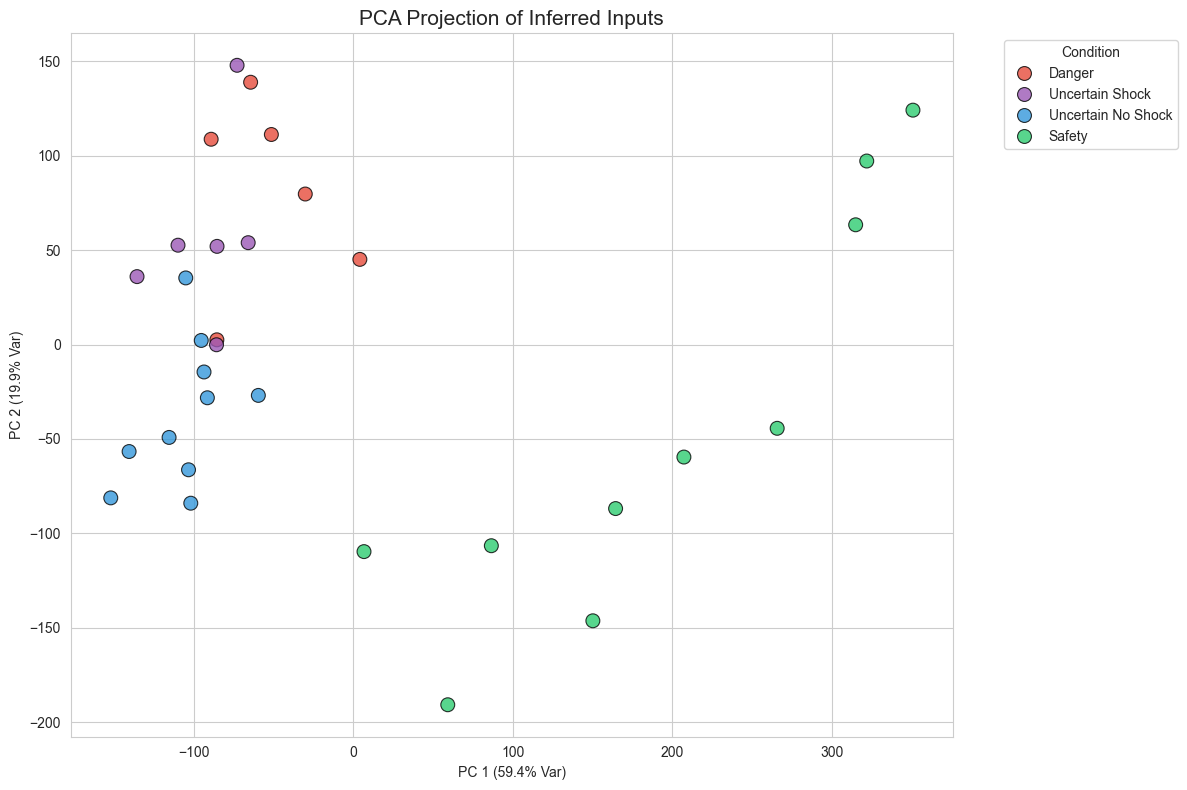

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array):
    """
    Reshapes data from (Trials, Time, Inputs) to (Trials * Inputs, Time)
    and performs PCA to compare with t-SNE results.
    """
    # 1. Reshape: (16, 400, 4) -> (16, 4, 400) -> (64, 400)
    n_trials, n_time, n_inputs = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)

    # 2. Define labels for the 64 points (Same as your t-SNE script)
    base_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 3. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 4. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=base_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title('PCA Projection of Inferred Inputs', fontsize=15)
    plt.xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    plt.ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the PCA comparison
plot_pca_stacked_inputs(inferred_inputs['Ctr'])

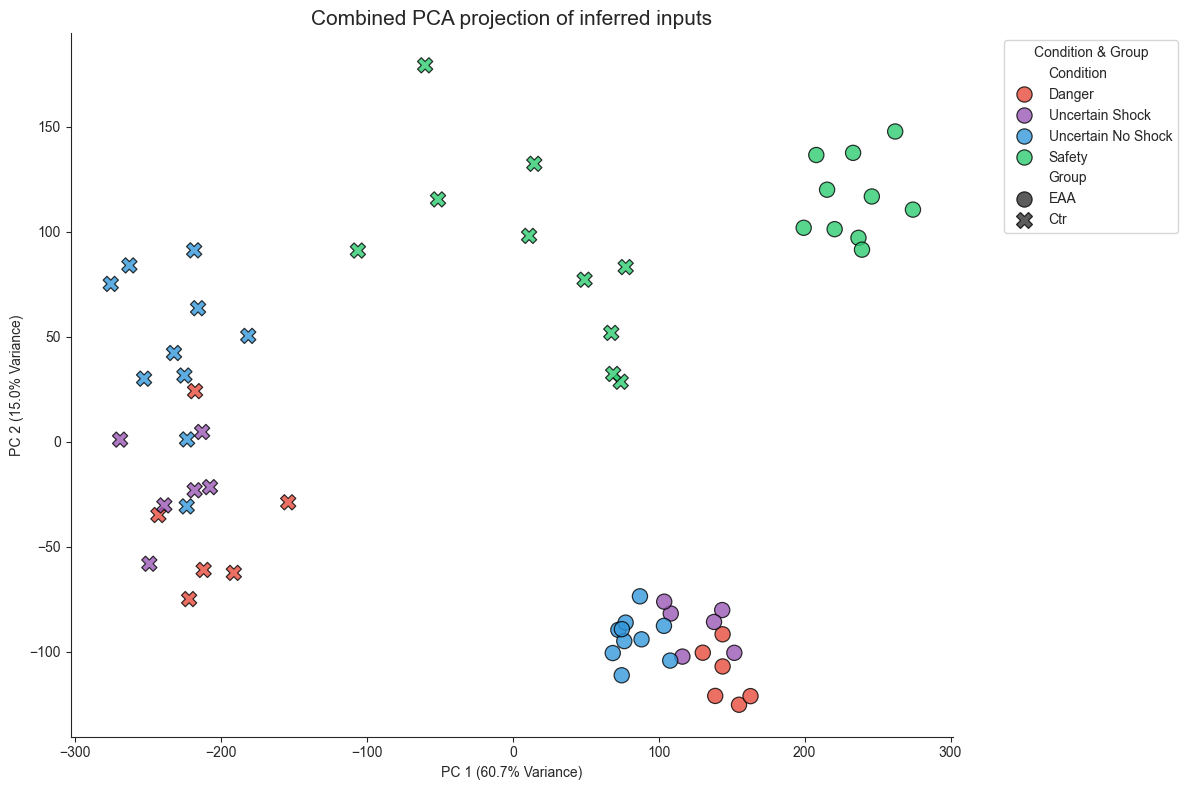

In [87]:
plot_pca_combined(inferred_inputs['EAA'], inferred_inputs['Ctr'],)

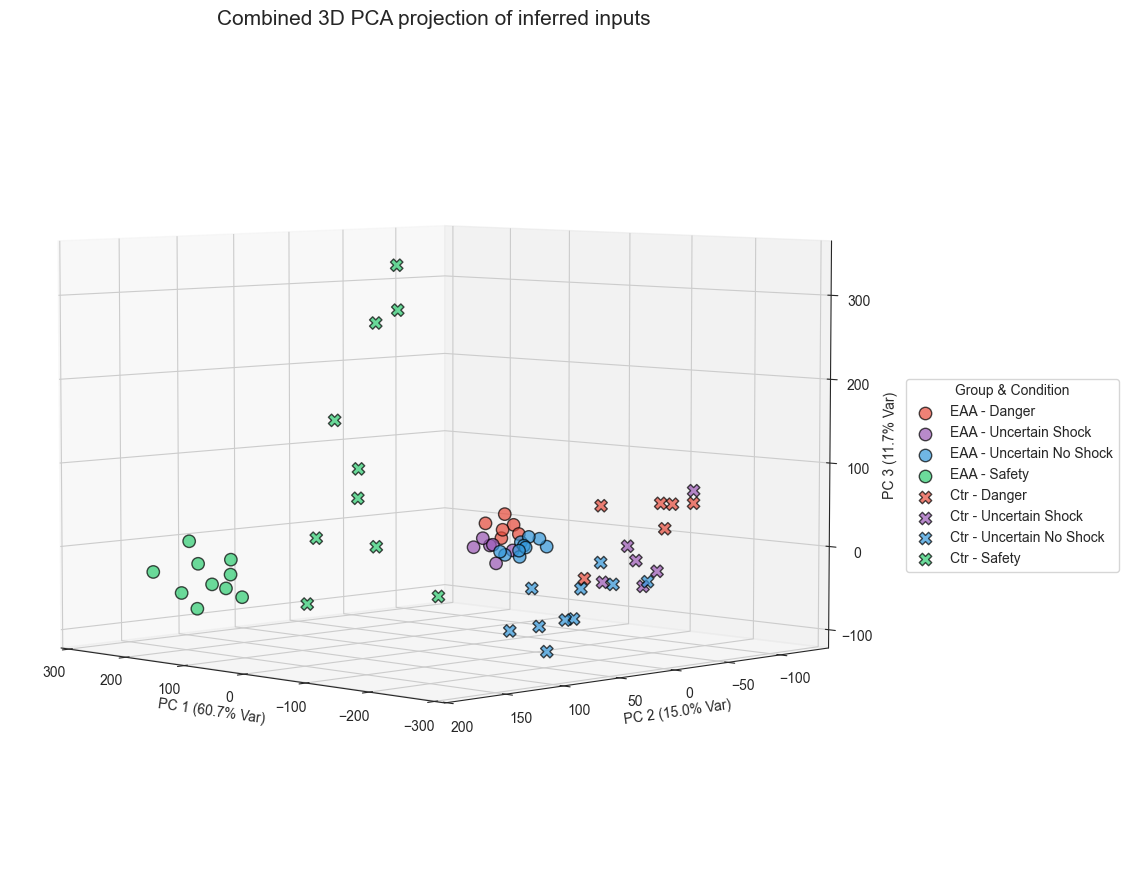

In [101]:
plot_pca_combined_3d(inferred_inputs['EAA'], inferred_inputs['Ctr'], 'Combined 3D PCA projection of inferred inputs', elev=5, azim=135)

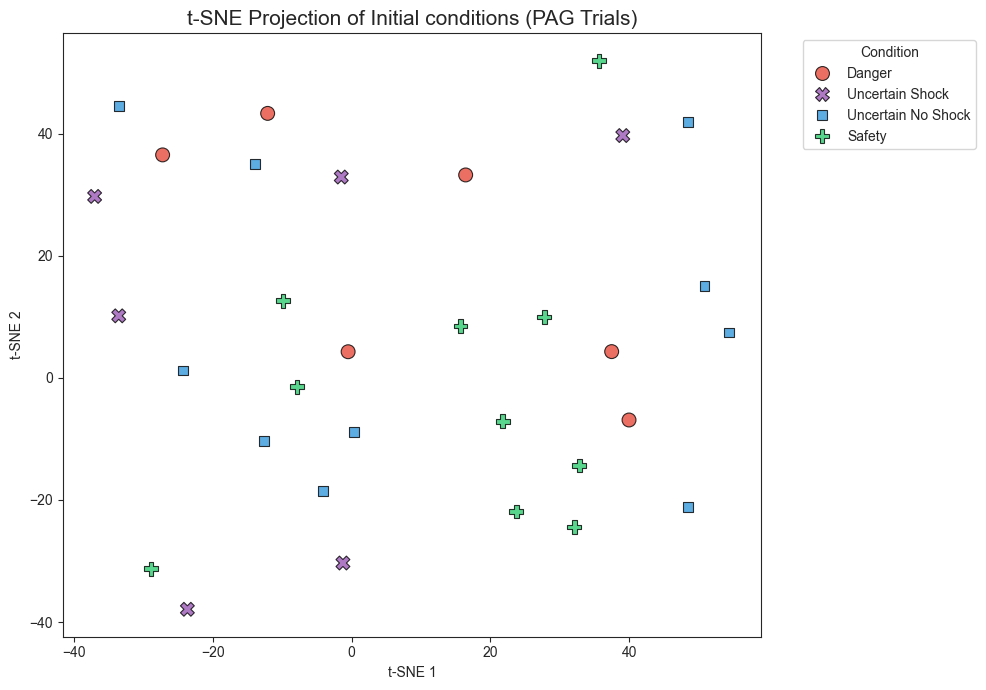

In [103]:
# t-SNE clustering of initial conditions

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_tsne_init_cond(data_array):
    """
    Projects trial data to 2D using t-SNE and colors by condition.
    data_array: np.ndarray of shape (n_trials, d_initial_condition) = (16, 64)
    """

    # 1. Define the conditions based on your trial counts
    # 4 Danger, 2 Uncertain Shock, 6 Uncertain No Shock, 4 Safety
    conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 2. Run t-SNE
    # perplexity should be smaller than n_samples (32)
    tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(data_array)

    # 3. Visualization
    plt.figure(figsize=(10, 7))
    sns.set_style("ticks")
    
    # Custom color palette for conditions
    palette = {
        'Danger': '#e74c3c',            # Red
        'Uncertain Shock': '#9b59b6',   # Purple
        'Uncertain No Shock': '#3498db',# Blue
        'Safety': '#2ecc71'             # Green
    }

    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1], 
        hue=conditions,
        palette=palette,
        s=100,
        style=conditions,
        edgecolor='black',
        alpha=0.8
    )

    plt.title('t-SNE Projection of Initial conditions (PAG Trials)', fontsize=15)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_tsne_init_cond(initial_conditions['Ctr'])